# Laboration: Maskininlärning

Denna arbetet ska genomföra analys av dataset om hjärt och kärlsjukdom
- EDA - Här inkluderas det dataöversikt, visualiseringar och kontroll av värden som saknas
- Feature Enginnering - Innebär manipulering och skapelse av nya features såsom BMI och blodtryckskategorier samt filtrera bort de orimliga värden.
- Modellval - Uppdelning av data, skalning, hyperparamteroptimering med GridSearchCV samt jämföra olika modeller.
- Rapportering - Skapelse av confusion matrix och klassifikationsrapport


In [1]:
# Importering av de nödvändiga bibliotek så att man kan datahantering, numeriska operationer och visualisering
import pandas as pd  # Hantera dataframes
import numpy as np   # Numeriska beräkningar
import matplotlib.pyplot as plt  # Visualisering med diagram
import seaborn as sns  # styla samt mer avancerade visualisering

# Importering av verktyg för att kunna utföra uppdelning av data och hyperparameteroptimering
from sklearn.model_selection import train_test_split, GridSearchCV  # Dela upp data för maskininlärning och söka över parametrar
from sklearn.preprocessing import StandardScaler, Normalizer  # För att kunna skala features

# Importering av maskininlärningsmodeller
from sklearn.ensemble import RandomForestClassifier  # Random Forest Classifier
from sklearn.svm import LinearSVC  # Linear Support Vector Classifier
from sklearn.neighbors import KNeighborsClassifier  # K-Nearest Neighbors

# Importering av utvärderingsmått
from sklearn.metrics import roc_auc_score  # ROC-AUC för utvärdering

In [2]:
# Läsar man in datasetet från csv-filen "cardio_train.csv" med semikolon som separator
df = pd.read_csv("cardio_train.csv", sep=";") 

# Säkerställning att datan har laddats korrekt
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# För att se fördelningen av hjärt-kärlsjukdom där 1 = sjuk och 0 = frisk
df["cardio"].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

In [4]:
# Visar fördelningen av kolumnen "cholesterol". 1 innebär normal, 2 är över normalt och 3 är extremt över normalt värde av cholesterol
df["cholesterol"].value_counts()

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

In [5]:
# Kontrollera datatyper för varje kolumn för att se ifall om alla är nummerisk
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [6]:
# Kontrollera om det finns saknade värden i datasetet
df.isna().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [7]:
# Omvandla "age" från dagar till år 
df["age"] = round(df["age"] / 365, 2)  
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.39,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.42,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51.66,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48.28,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47.87,1,156,56.0,100,60,1,1,0,0,0,0


In [8]:
# Beräkning av antalet patienter med och utan hjärt-kärlsjukdom där index 0 är utan och index 1 är med. Hyfsat jämnfördelat
cardiovascular = df["cardio"].value_counts().values 
cardiovascular

array([35021, 34979])

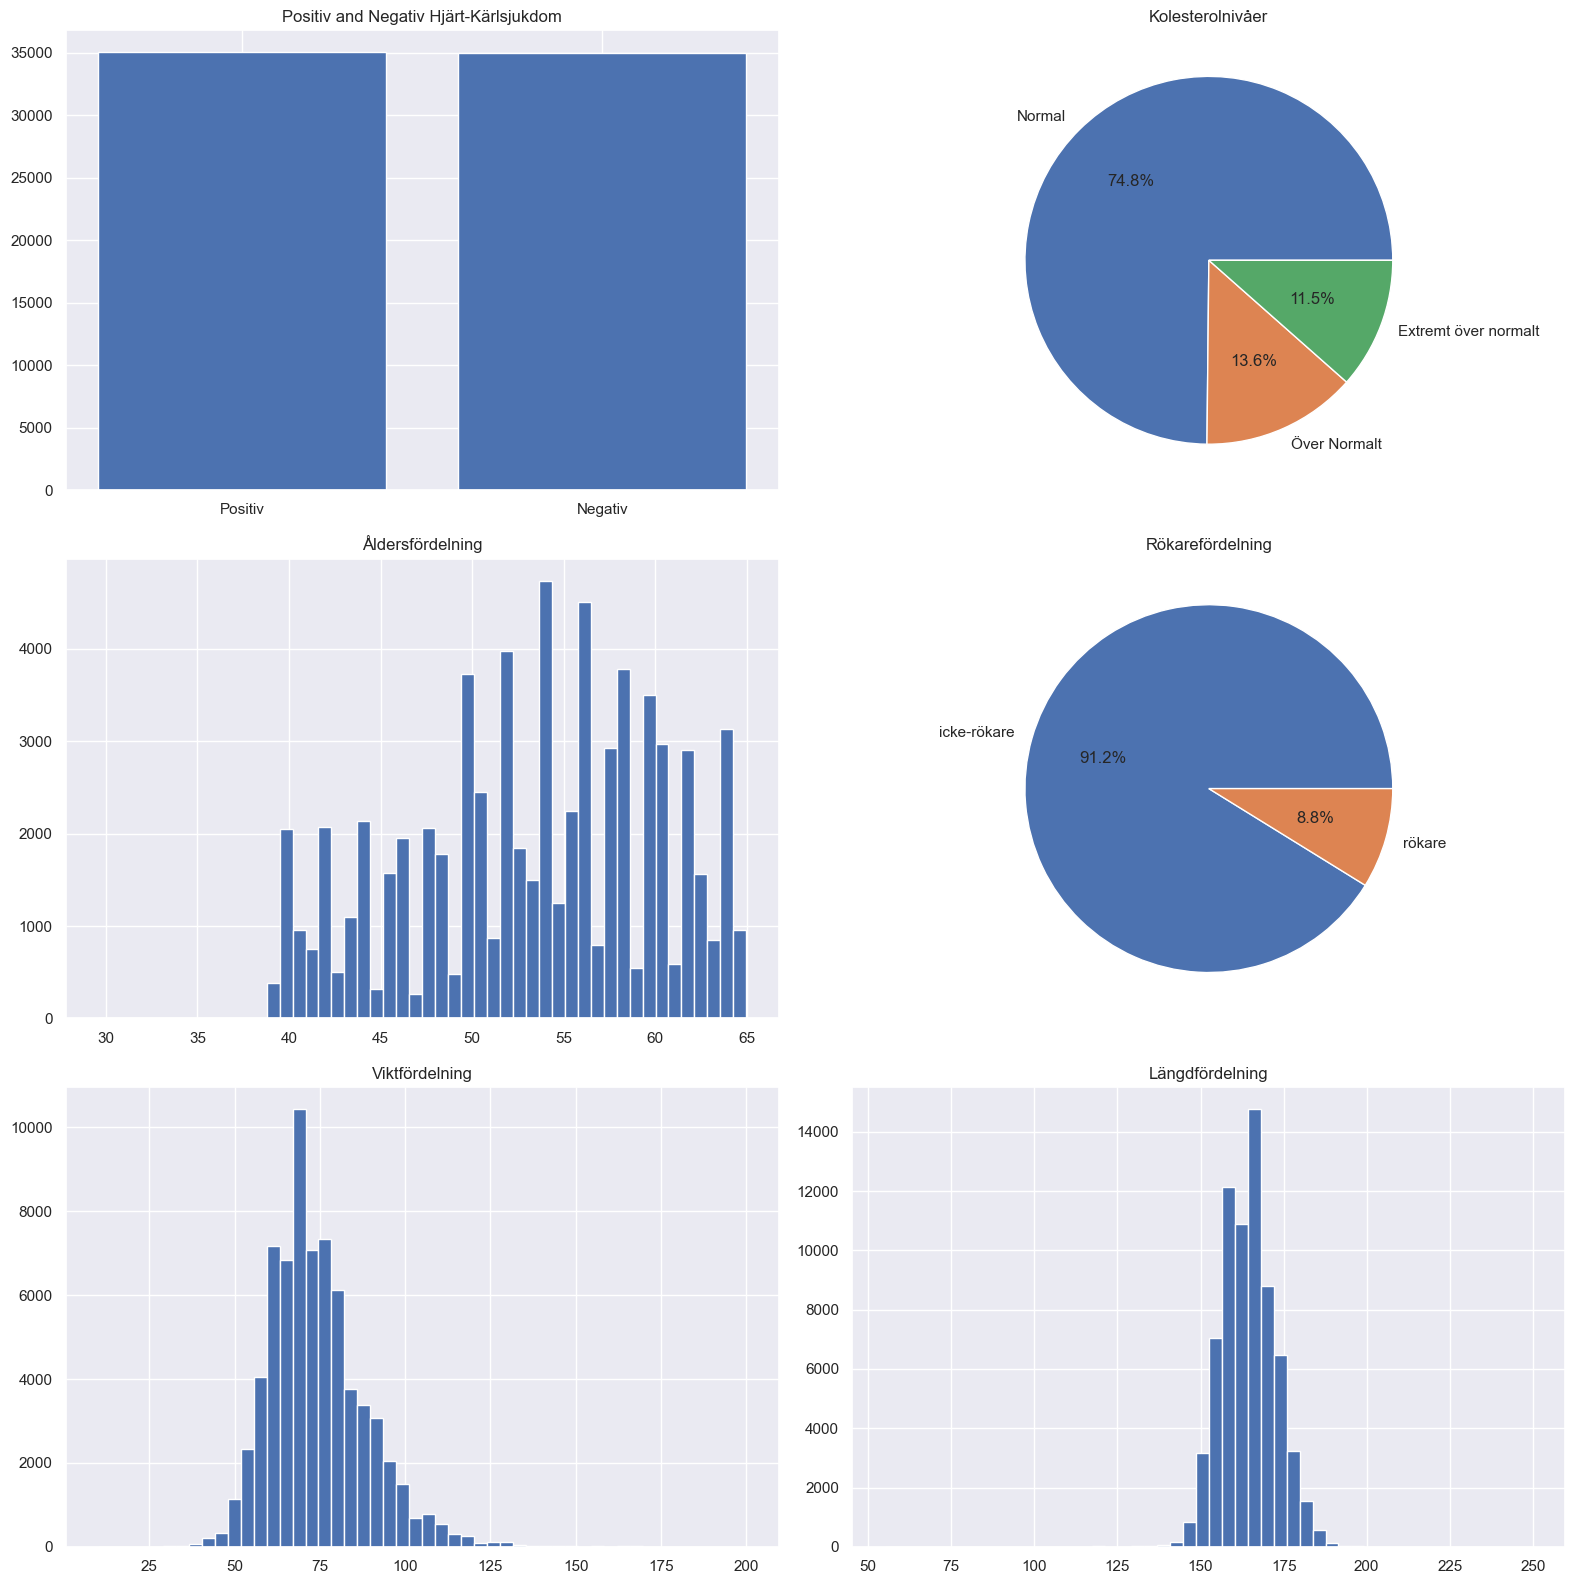

In [9]:
# Ändrar visningstema via seaborn
sns.set_theme()

# Skapa en figur med flera subplots (3 rader, 2 kolumner)
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(nrows=3, ncols=2, figsize=(16, 16))

# Subplot 1: Barplot för hjärt-kärlsjukdom (Positiva/negativa)
cardiovascular_labels = ["Positiv", "Negativ"]
ax1.bar(cardiovascular_labels, cardiovascular)  # Rita stapeldiagram
ax1.set_title("Positiv and Negativ Hjärt-Kärlsjukdom")

# Subplot 2: Pajdiagram för kolesterolnivåer (1 = normal, 2 = över normalt, 3 = extremt över normalt), avrundning till 1 decimal.
ax2.pie(df["cholesterol"].value_counts().values, labels=["Normal", "Över Normalt", "Extremt över normalt"], autopct="%1.1f%%")
ax2.set_title("Kolesterolnivåer")

# Subplot 3: Histogram för åldersfördelning
ax3.hist(df["age"], bins=50) 
ax3.set_title("Åldersfördelning")

# Subplot 4: Pajdiagram för rökvanor (0 = icke-rökare, 1 = rökare)
ax4.pie(df["smoke"].value_counts().values, labels=["icke-rökare", "rökare"], autopct="%1.1f%%")
ax4.set_title("Rökarefördelning")

# Subplot 5: Histogram för viktfördelning
ax5.hist(df["weight"], bins=50)
ax5.set_title("Viktfördelning")

# Subplot 6: Histogram för längdfördelning
ax6.hist(df["height"], bins=50)
ax6.set_title("Längdfördelning")

# Visa diagrammer
plt.tight_layout()
plt.show()

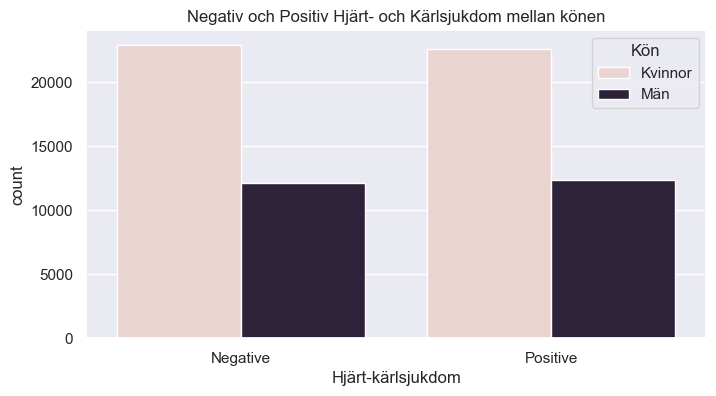

In [10]:
# Skapar ny figure
fig, ax7 = plt.subplots(figsize=(8, 4))

# Rita countplot med "cardio" på x-axeln och färg baserat på "gender"
sns.countplot(data=df, x="cardio", hue="gender", ax=ax7)

# Förändra tick labels från 0/1 till negative/positive
ax7.set_xticks([0, 1])
ax7.set_xticklabels(["Negative", "Positive"])

# Ändra namn på x-axeln
ax7.set_xlabel("Hjärt-kärlsjukdom")

# Ändra titelnamnet
ax7.set_title("Negativ och Positiv Hjärt- och Kärlsjukdom mellan könen")

# Ändra legendens labels (0 = kvinnor, 1 = män)
ax7.legend(title="Kön", labels=["Kvinnor", "Män"])

# Visa diagrammet
plt.show()

In [11]:
# Beräknnar Body Mass Index (BMI) med formeln: vikt (kg) / (längd (m))^2
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)
df["bmi"] = df["bmi"].round(1)  # Avrundning BMI till en decimal

# Filtrera bort orimliga BMI-värden (exempelvis under 6 och över 260). Världens högsta rekord på BMI ligger på 251.1 och lägsta ligger på 6.7 därför tänker ha kvar värden mellan 260 och 6 ifall om ny person dyker upp som slår rekorden.
df = df[(df["bmi"] <= 260) & (df["bmi"] >= 6)]

# Kontrollera minsta och största BMI-värde som finns med i datan
df["bmi"].min(), df["bmi"].max()

(np.float64(7.0), np.float64(237.8))

In [12]:
# Definiera bin-gränser och tillhörande labels för BMI-nivåer
bins = [6, 18.4, 24.9, 29.9, 34.9, 39.9, 260]
labels = ["Underweight", "Normal weight", "Overweight", 
          "Obese Class 1", "Obese Class 2", "Obese Class 3"]

# Skapa en ny kolumn "bmi_levels" baserat på BMI-värdena och de definierade bins
df["bmi_levels"] = pd.cut(df["bmi"], bins=bins, labels=labels)

# Kontrollera att BMI-nivåerna har skapats genom att visa fördelningen
df["bmi_levels"].value_counts()

bmi_levels
Overweight       25546
Normal weight    25216
Obese Class 1    12302
Obese Class 2     4402
Obese Class 3     1902
Underweight        627
Name: count, dtype: int64

In [13]:
# Filtrera bort orimliga värden för blodtryck. Världens rekord på högsta blodtryck är 370/360 ifall om någon dyker upp i datan som slår rekorden därför satt man dessa gränser.  Låg blodtryck räknas vara under 90/60 för att ha med exträma världen så ska nedre gränsen av 45/30 inkluderas.
# ap_hi (systoliskt) ska vara mellan 45 och 380
# ap_lo (diastoliskt) ska vara mellan 30 och 370 och lägre än ap_hi
df = df[(df["ap_hi"] <= 380) & (df["ap_hi"] >= 45) &
        (df["ap_lo"] <= 370) & (df["ap_lo"] >= 30) &
        (df["ap_lo"] < df["ap_hi"])]

# Kontrollerar storleken på datasetet efter filtrering
df.shape

(68674, 15)

In [14]:
# Definierar de villkor och motsvarande labels för blodtrycksnivåer
conditions = [
    (df["ap_hi"] < 90) | (df["ap_lo"] < 60),  # Lågt blodtryck
    (df["ap_hi"] < 120) & (df["ap_lo"] < 80),    # Gränsen gällande hälsosamt blodtryck
    (df["ap_hi"] >= 120) & (df["ap_hi"] < 130) & (df["ap_lo"] < 80),  # Gränsen gällande förhöjt systoliskt
    ((df["ap_hi"] >= 130) & (df["ap_hi"] < 140)) | ((df["ap_lo"] >= 80) & (df["ap_lo"] < 90)),  # Gränsen gällande stage 1 hypertension
    ((df["ap_hi"] >= 140) & (df["ap_hi"] < 180)) | ((df["ap_lo"] >= 90) & (df["ap_lo"] < 120)),  # Gränsen gällande stage 2 hypertension
    (df["ap_hi"] >= 180) | (df["ap_lo"] >= 120)  # Gränsen gällande hypertension crisis
]

labels_bp = [
    "Below Optimal",
    "Healthy",
    "Elevated",
    "Stage 1 hypertension",
    "Stage 2 hypertension",
    "Hypertension crisis"
]

# Skapar ny kolumn "blood_pressure_levels" baserat på villkoren
df["blood_pressure_levels"] = np.select(conditions, labels_bp, default="Unknown")

# För att se fördelningen av blodtrycksnivåer
df["blood_pressure_levels"].value_counts()

blood_pressure_levels
Stage 1 hypertension    39759
Stage 2 hypertension    16068
Healthy                  9417
Elevated                 3101
Below Optimal             181
Hypertension crisis       148
Name: count, dtype: int64

C:\Users\AptiD\AppData\Local\Temp\ipykernel_18440\3531317130.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratio = df.groupby(feature)["cardio"].mean()


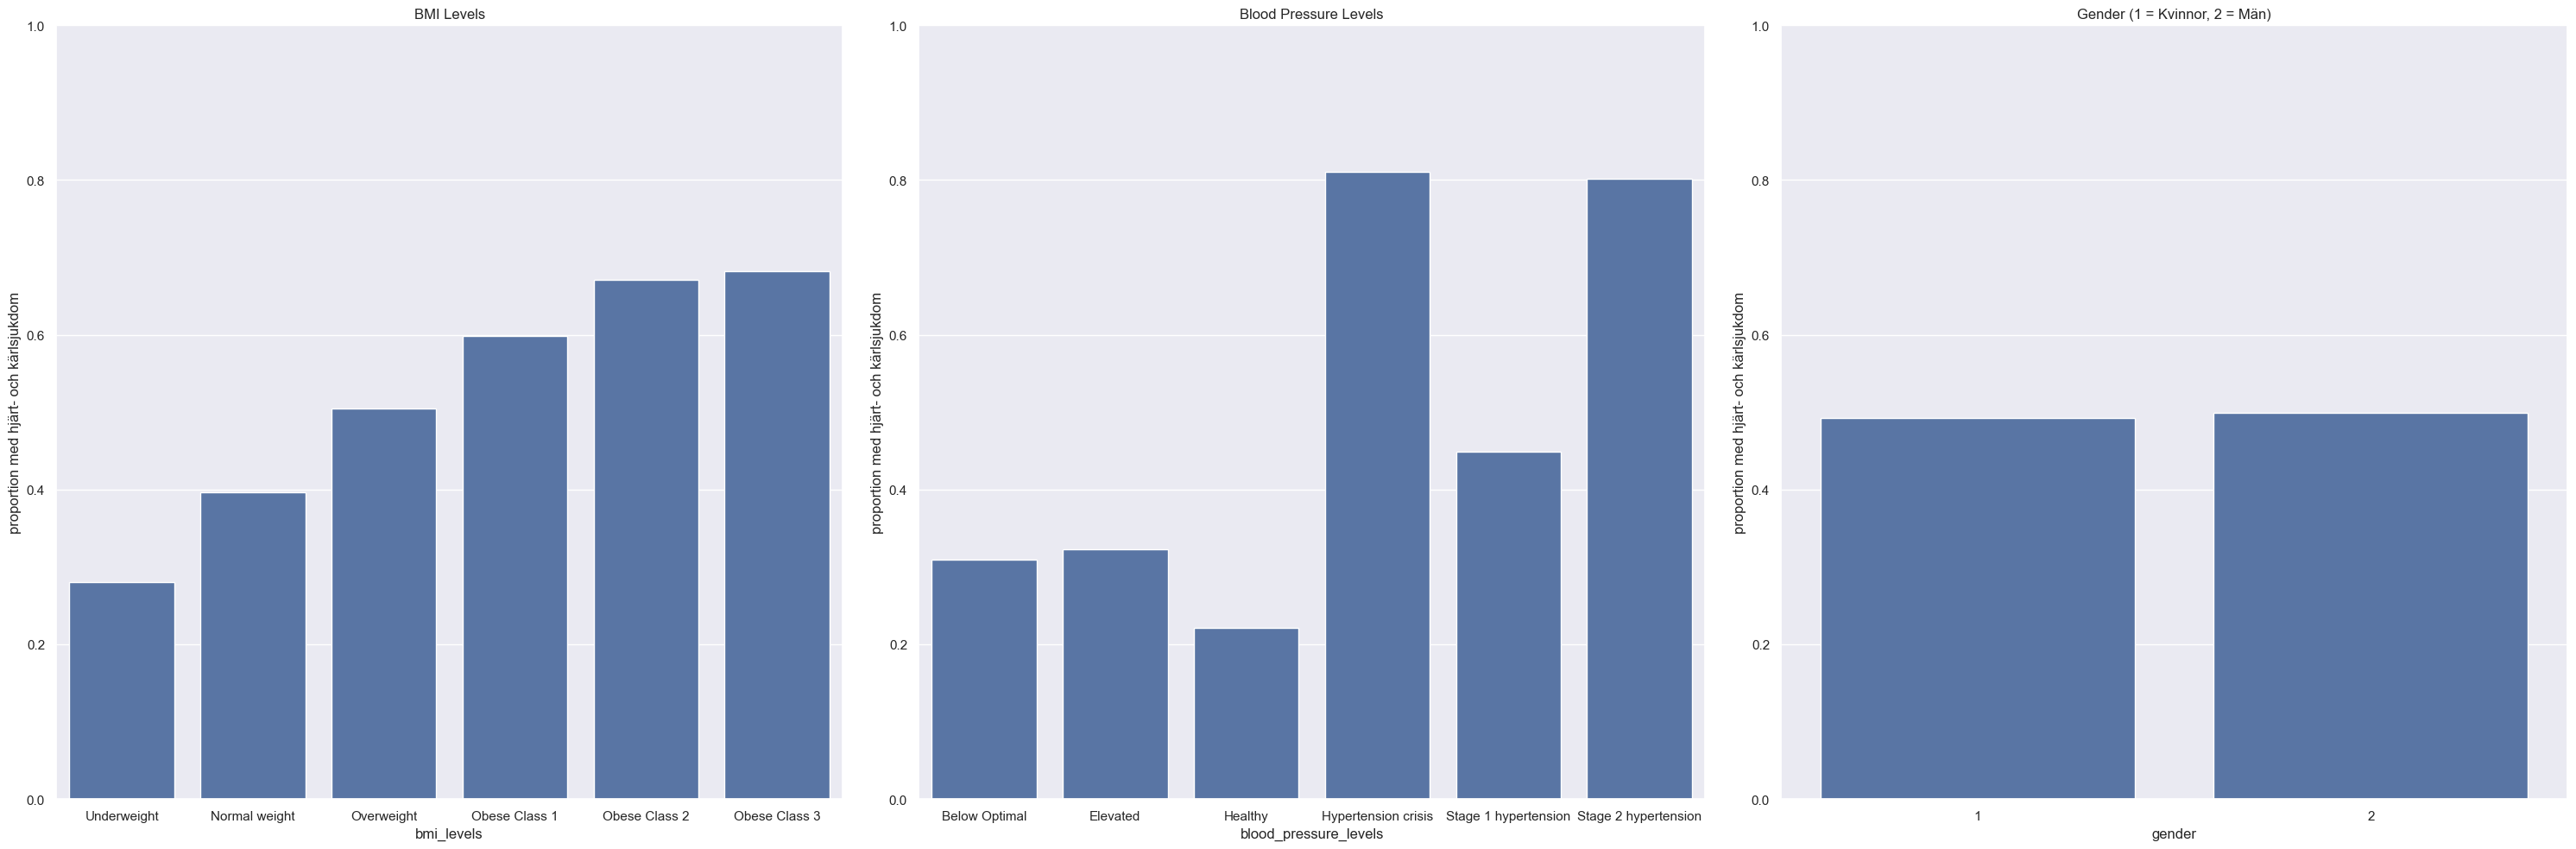

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(30, 10))

# Grupperar "bmi_levels", "blood_pressure_levels" och "gender"
for ax, feature, title in zip(
    axs,
    ["bmi_levels", "blood_pressure_levels", "gender"],
    ["BMI Levels", "Blood Pressure Levels", "Gender (1 = Kvinnor, 2 = Män)"]):
    
    # Beräknar andelen (proportion) av positiva fall för varje kategori
    ratio = df.groupby(feature)["cardio"].mean()
    sns.barplot(x=ratio.index, y=ratio.values, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("proportion med hjärt- och kärlsjukdom")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


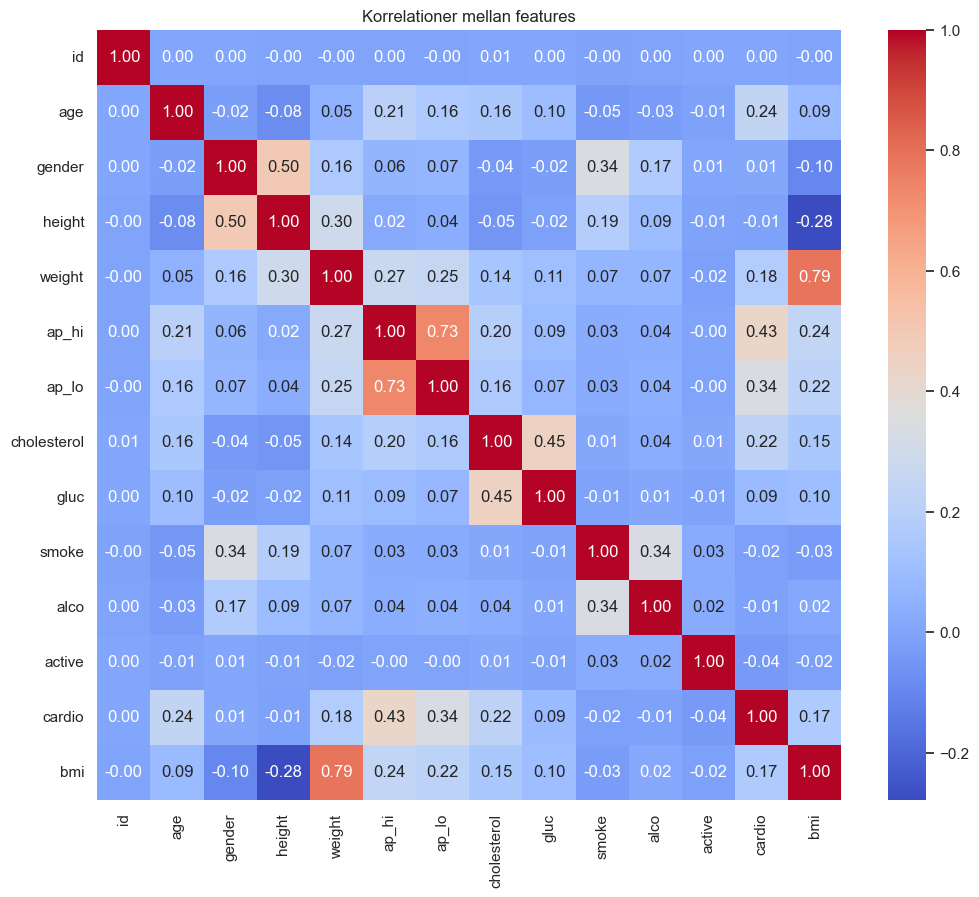

In [16]:
# Beräkna korrelationsmatrisen använder av enbart numeriska kolumner
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Skapa en heatmap med seaborn
plt.figure(figsize=(12, 10)) 
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")  # Rita heatmap med värden med 2 decimaler
plt.title("Korrelationer mellan features")
plt.show()


- Man kan se vissa features är starkt korrelerade de som ligger nära 1 eller -1 det positiva innebär om den ena ökar så påverkas den andra med ökning den negativa är är att det sker
motsatsa om den ökar.
- Eftersom BMI beräknas utifrån vikt och längd, det påverkas av vikt och längd
- Man kan även se att cardio påverkas av ap_hi och ap_lo alltså blodtrycksvärdena samt av ålder, vikt och kolesterol värder.

In [17]:
# Skapar ny variabel med kopia av dataframe som redan har innehåller feature engineering med påläggda kolumner från tidigare
df_model1 = df.copy() 

# Förbereder första datasetet och tar bort irrelevanta features för modelleringen
df_model1 = df_model1.drop(["ap_hi", "ap_lo", "height", "weight", "bmi"], axis=1)

# Skapar one-hot encoding på de kategoriska features
df_model1 = pd.get_dummies(df_model1, columns=["gender", "bmi_levels", "blood_pressure_levels"]).astype(int)

# Ändrar namn på kolumn gender_1 och gender_2
df_model1 = df_model1.rename(columns={"gender_1":"gender_female","gender_2":"gender_male"})

# Se för att verifiera förändringarna
df_model1.head()

,id,age,cholesterol,gluc,smoke,alco,active,cardio,gender_female,gender_male,...,bmi_levels_Overweight,bmi_levels_Obese Class 1,bmi_levels_Obese Class 2,bmi_levels_Obese Class 3,blood_pressure_levels_Below Optimal,blood_pressure_levels_Elevated,blood_pressure_levels_Healthy,blood_pressure_levels_Hypertension crisis,blood_pressure_levels_Stage 1 hypertension,blood_pressure_levels_Stage 2 hypertension
0,0,50,1,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,1,55,3,1,0,0,1,1,1,0,...,0,1,0,0,0,0,0,0,0,1
2,2,51,3,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,1,0
3,3,48,1,1,0,0,1,1,0,1,...,1,0,0,0,0,0,0,0,0,1
4,4,47,1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0


In [18]:
# Uppdelning av data i X och y
X = df_model1.drop("cardio", axis=1)  
y = df_model1["cardio"]

# Skapar random state
np.random.seed(42)

# Uppdelning av data i tränings-/valderingsdata motsvarar 85% och resten testdata
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, 
                                                    test_size=0.15, # Har 15% som testdata
                                                    stratify=y) # Ser till att splitten behåller samma andel procentuell y fördelning alltså fördelning med 0 och 1

# Validering ska vara 15% av hela datan
val_size = 0.15 / 0.85  # För att få exakt samma antal som testdata


# Ytterligare uppdelning av tränings-/valideringsdata i träningsdata 70% av hela datan och valideringsdata 15%
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                  test_size=val_size,
                                                  stratify=y_train_val)

# Skapar instansen av StandardScaler
scaler = StandardScaler()

# Skapar instansen av Normalizer
normalize = Normalizer()

# Använder skalaren samt transformera tränings-, validerings- och testdata så att deras features får jämnlikhet och inte domineras av deras värderna vid träning.
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# Använder normalisering för datan.
X_train_normalize = normalize.fit_transform(X_train)
X_val_normalize = normalize.transform(X_val)
X_test_normalize = normalize.transform(X_test)

# Visar dimensionerna på de datasetten som är uppdelade
print("Träningsdata:", X_train.shape, "| Valideringsdata:", X_val.shape, "| Testdata:", X_test.shape)

Träningsdata: (48071, 21) | Valideringsdata: (10301, 21) | Testdata: (10302, 21)


In [19]:
df_model2 = df.copy() 

# Förbereder andra datasetet och tar bort irrelevanta features för modelleringen
df_model2 = df_model2.drop(["bmi_levels", "blood_pressure_levels", "height", "weight"], axis=1)

# Skapar one-hot encoding på de kategoriska features
df_model2 = pd.get_dummies(df_model2, columns=["gender"]).astype(int)

# Ändrar namn på kolumn gender_1 och gender_2
df_model2 = df_model2.rename(columns={"gender_1":"gender_female","gender_2":"gender_male"})

# Se för att verifiera förändringarna
df_model2.head()

,id,age,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi,gender_female,gender_male
0,0,50,110,80,1,1,0,0,1,0,22,0,1
1,1,55,140,90,3,1,0,0,1,1,34,1,0
2,2,51,130,70,3,1,0,0,0,1,23,1,0
3,3,48,150,100,1,1,0,0,1,1,28,0,1
4,4,47,100,60,1,1,0,0,0,0,23,1,0


In [ ]:
# Uppdelning av data i X och y
X2 = df_model2.drop("cardio", axis=1)  
y2 = df_model2["cardio"]

# Skapar random state
np.random.seed(42)

# Uppdelning av data i tränings-/valderingsdata motsvarar 85% och resten testdata
X_train_val2, X_test2, y_train_val2, y_test2 = train_test_split(X2, y2, 
                                                    test_size=0.15, # Har 15% som testdata
                                                    stratify=y2) # Ser till att splitten behåller samma andel procentuell y fördelning alltså fördelning med 0 och 1

# Validering ska vara 15% av hela datan
val_size2 = 0.15 / 0.85  # För att få exakt samma antal som testdata


# Ytterligare uppdelning av tränings-/valideringsdata i träningsdata 70% av hela datan och valideringsdata 15%
X_train2, X_val2, y_train2, y_val2 = train_test_split(X_train_val2, y_train_val2,
                                                  test_size=val_size2,
                                                  stratify=y_train_val2)

# Skapar instansen av StandardScaler
scaler = StandardScaler()

# Skapar instansen av Normalizer
normalize = Normalizer()

# Använder skalaren samt transformera tränings-, validerings- och testdata så att deras features får jämnlikhet och inte domineras av deras värderna vid träning.
X_train_scaled2 = scaler.fit_transform(X_train2)
X_val_scaled2 = scaler.transform(X_val2)
X_test_scaled2 = scaler.transform(X_test2)

# Använder normalisering för datan. Det Arbetar på enskilda rader och gör att varje datapunkt får en enhetslängd.
X_train_normalize2 = normalize.fit_transform(X_train2)
X_val_normalize2 = normalize.transform(X_val2)
X_test_normalize2 = normalize.transform(X_test2)

# Visar dimensionerna på de datasetten som är uppdelade
print("Träningsdata:", X_train2.shape, "| Valideringsdata:", X_val2.shape, "| Testdata:", X_test2.shape)

Träningsdata: (48071, 12) | Valideringsdata: (10301, 12) | Testdata: (10302, 12)


In [21]:
# Skapar random state
np.random.seed(42)

# Måste se till sätta realistiska inställningar pga begränsningar på hemdatorer.

# Skapar modeller och deras hyperparametergrids
models = {
    "LinearSVC": {
        "model": LinearSVC(max_iter=10000),  # Linear SVC med ökat max_iterations
        "params": {"C": [0.01, 0.1, 1, 10, 100]}  # Styrka på regularisering
                 },
    
    "KNN": {
        "model": KNeighborsClassifier(),  # K-Nearest Neighbors
        "params": {"n_neighbors": [3, 5, 7, 9],  # Antal neighbors
                   "p": [1, 2]} # 1: Manhattan distans, 2: Euklidiskt distans
           },
    
    "RandomForest": {
        "model": RandomForestClassifier(),  # Random Forest Classifier ensemble modell
        "params": {"n_estimators": [50, 100, 200],  # Antal träder
                   "max_depth": [None, 5, 10],        # Max djup på träden
                   "min_samples_split": [2, 5, 10]}    # Minst antal samples för att dela noder
                     }
         }

# Verifiera att modellerna är korrekt inställda
models

{'LinearSVC': {'model': LinearSVC(max_iter=10000),
  'params': {'C': [0.01, 0.1, 1, 10, 100]}},
 'KNN': {'model': KNeighborsClassifier(),
  'params': {'n_neighbors': [3, 5, 7, 9], 'p': [1, 2]}},
 'RandomForest': {'model': RandomForestClassifier(),
  'params': {'n_estimators': [50, 100, 200],
   'max_depth': [None, 5, 10],
   'min_samples_split': [2, 5, 10]}}}

## Standard Scaled Dataset 1

In [22]:
# Skapar random state
np.random.seed(42)

# Skapar den tomma dictionaries för att kunna lagra resultaten för varje modell en tom ordbok för att lagra resultaten för varje modell (df_model1)
results = {}

# Iterera över varje modell i dictionaries "models"
for model_name, mp in models.items():
    print(f"\n--- {model_name} (df_model1) ---")
    
    # Initiera GridSearchCV med aktuell modell och dess hyperparametergrid
    grid = GridSearchCV(
        estimator=mp["model"],
        param_grid=mp["params"], # Dictioneras med hyperparametrar och värden man vill testa under grid searchen
        scoring="roc_auc", # Dessa är obelanserade klasser så utgvärderingsmått ROC-AUC är lämplig
        cv=5, # Använder av oss 5 faldiga cross validation för att säkerställa resultat
        n_jobs=-1, # Använder fullständig datorkraft processorer för att utföra sökningen
        verbose=2 # Verbose på nivå 2 ger detaljerad information under sökning
    )
    
    # Träna modellen med GridSearchCV på den skalade träningsdatan för df_model1
    grid.fit(X_train_scaled, y_train)
    
    # När det gäller LinearSVC används decision_function (vilket fungerar med roc_auc) eftersom predict_proba inte finns
    try:
        y_val_pred = grid.predict_proba(X_val_scaled)[:, 1]
    except AttributeError:
        # Om predict_proba inte finns, använd decision_function
        y_val_pred = grid.decision_function(X_val_scaled)
    
    # Beräkning av ROC-AUC på valideringsdatan
    auc = roc_auc_score(y_val, y_val_pred)
    
    # Spara de bästa parametrarna och ROC-AUC för modellen
    results[model_name] = {
        "best_params": grid.best_params_,
        "validation_roc_auc": auc
    }
    
    print("Bästa parametrar:", grid.best_params_)
    print("Validation ROC-AUC:", auc)

# Sammanfattning av resultaten för df_model1
print("\nSammanfattning av modellresultat (df_model1):")
for model_name, res in results.items():
    print(f"{model_name}: ROC-AUC = {res['validation_roc_auc']:.3f}, Bästa parametrar = {res['best_params']}")



--- LinearSVC (df_model1) ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Bästa parametrar: {'C': 0.01}
Validation ROC-AUC: 0.7609580586834601

--- KNN (df_model1) ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Bästa parametrar: {'n_neighbors': 9, 'p': 2}
Validation ROC-AUC: 0.727329886731904

--- RandomForest (df_model1) ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Bästa parametrar: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Validation ROC-AUC: 0.7624390567577064

Sammanfattning av modellresultat (df_model1):
LinearSVC: ROC-AUC = 0.761, Bästa parametrar = {'C': 0.01}
KNN: ROC-AUC = 0.727, Bästa parametrar = {'n_neighbors': 9, 'p': 2}
RandomForest: ROC-AUC = 0.762, Bästa parametrar = {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


## Normalized Dataset 1

In [28]:
# Skapar random state
np.random.seed(42)

# Skapar den tomma dictionaries för att kunna lagra resultaten för varje modell en tom ordbok för att lagra resultaten för varje modell (df_model1)
results = {}

# Iterera över varje modell i dictionaries "models"
for model_name, mp in models.items():
    print(f"\n--- {model_name} (df_model1) ---")
    
    # Initiera GridSearchCV med aktuell modell och dess hyperparametergrid
    grid = GridSearchCV(
        estimator=mp["model"],
        param_grid=mp["params"], # Dictioneras med hyperparametrar och värden man vill testa under grid searchen
        scoring="roc_auc", # Dessa är obelanserade klasser så utgvärderingsmått ROC-AUC är lämplig
        cv=5, # Använder av oss 5 faldiga cross validation för att säkerställa resultat
        n_jobs=-1, # Använder fullständig datorkraft processorer för att utföra sökningen
        verbose=2 # Verbose på nivå 2 ger detaljerad information under sökning
    )
    
    # Träna modellen med GridSearchCV på den normaliserad träningsdatan för df_model1
    grid.fit(X_train_normalize, y_train)
    
    # När det gäller LinearSVC används decision_function (vilket fungerar med roc_auc) eftersom predict_proba inte finns
    try:
        y_val_pred = grid.predict_proba(X_val_normalize)[:, 1]
    except AttributeError:
        # Om predict_proba inte finns, använd decision_function
        y_val_pred = grid.decision_function(X_val_normalize)
    
    # Beräkning av ROC-AUC på valideringsdatan
    auc = roc_auc_score(y_val, y_val_pred)
    
    # Spara de bästa parametrarna och ROC-AUC för modellen
    results[model_name] = {
        "best_params": grid.best_params_,
        "validation_roc_auc": auc
    }
    
    print("Bästa parametrar:", grid.best_params_)
    print("Validation ROC-AUC:", auc)

# Sammanfattning av resultaten för df_model1
print("\nSammanfattning av modellresultat (df_model1):")
for model_name, res in results.items():
    print(f"{model_name}: ROC-AUC = {res['validation_roc_auc']:.3f}, Bästa parametrar = {res['best_params']}")



--- LinearSVC (df_model1) ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Bästa parametrar: {'C': 100}
Validation ROC-AUC: 0.7141366832700714

--- KNN (df_model1) ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Bästa parametrar: {'n_neighbors': 9, 'p': 1}
Validation ROC-AUC: 0.6990152944352204

--- RandomForest (df_model1) ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Bästa parametrar: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Validation ROC-AUC: 0.7428608940805318

Sammanfattning av modellresultat (df_model1):
LinearSVC: ROC-AUC = 0.714, Bästa parametrar = {'C': 100}
KNN: ROC-AUC = 0.699, Bästa parametrar = {'n_neighbors': 9, 'p': 1}
RandomForest: ROC-AUC = 0.743, Bästa parametrar = {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


## Standard Scaled Dataset 2

In [24]:
# Skapar random state
np.random.seed(42)

# Skapar den tomma dictionaries för att kunna lagra resultaten för varje modell en tom ordbok för att lagra resultaten för varje modell (df_model2)
results2 = {}

# Iterera över varje modell i ordboken "models"
for model_name, mp in models.items():
    print(f"\n--- {model_name} (df_model2) ---")
    
    # Initiera GridSearchCV med aktuell modell och dess hyperparametergrid
    grid2 = GridSearchCV(
        estimator=mp["model"],
        param_grid=mp["params"],
        scoring="roc_auc",
        cv=5,
        n_jobs=-1,
        verbose=2
    )
    
    # Träna modellen med GridSearchCV på den skalade träningsdatan för df_model2
    grid2.fit(X_train_scaled2, y_train2)
    
    # När det gäller LinearSVC används decision_function (vilket fungerar med roc_auc) eftersom predict_proba inte finns
    try:
        y_val_pred2 = grid2.predict_proba(X_val_scaled2)[:, 1]
    except AttributeError:
        # Om predict_proba inte finns, använd decision_function
        y_val_pred2 = grid2.decision_function(X_val_scaled2)
    
    # Beräkna ROC-AUC på valideringsdatan
    auc2 = roc_auc_score(y_val2, y_val_pred2)
    
    # Spara de bästa parametrarna och ROC-AUC för modellen
    results2[model_name] = {
        "best_params": grid2.best_params_,
        "validation_roc_auc": auc2
    }
    
    print("Bästa parametrar:", grid2.best_params_)
    print("Validation ROC-AUC:", auc2)

# Sammanfattning av resultaten för df_model2
print("\nSammanfattning av modellresultat (df_model2):")
for model_name, res in results2.items():
    print(f"{model_name}: ROC-AUC = {res['validation_roc_auc']:.3f}, Bästa parametrar = {res['best_params']}")


--- LinearSVC (df_model2) ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Bästa parametrar: {'C': 100}
Validation ROC-AUC: 0.7855328697650641

--- KNN (df_model2) ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Bästa parametrar: {'n_neighbors': 9, 'p': 1}
Validation ROC-AUC: 0.7583423061088768

--- RandomForest (df_model2) ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Bästa parametrar: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Validation ROC-AUC: 0.7933703064466753

Sammanfattning av modellresultat (df_model2):
LinearSVC: ROC-AUC = 0.786, Bästa parametrar = {'C': 100}
KNN: ROC-AUC = 0.758, Bästa parametrar = {'n_neighbors': 9, 'p': 1}
RandomForest: ROC-AUC = 0.793, Bästa parametrar = {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


## Normalized Dataset 2

In [25]:
# Skapar random state
np.random.seed(42)

# Skapar den tomma dictionaries för att kunna lagra resultaten för varje modell en tom ordbok för att lagra resultaten för varje modell (df_model2)
results2 = {}

# Iterera över varje modell i ordboken "models"
for model_name, mp in models.items():
    print(f"\n--- {model_name} (df_model2) ---")
    
    # Initiera GridSearchCV med aktuell modell och dess hyperparametergrid
    grid2 = GridSearchCV(
        estimator=mp["model"],
        param_grid=mp["params"],
        scoring="roc_auc",
        cv=5,
        n_jobs=-1,
        verbose=2
    )
    
    # Träna modellen med GridSearchCV på den normaliserad träningsdatan för df_model2
    grid2.fit(X_train_normalize2, y_train2)
    
    # När det gäller LinearSVC används decision_function (vilket fungerar med roc_auc) eftersom predict_proba inte finns
    try:
        y_val_pred2 = grid2.predict_proba(X_val_normalize2)[:, 1]
    except AttributeError:
        # Om predict_proba inte finns, använd decision_function
        y_val_pred2 = grid2.decision_function(X_val_normalize2)
    
    # Beräkna ROC-AUC på valideringsdatan
    auc2 = roc_auc_score(y_val2, y_val_pred2)
    
    # Spara de bästa parametrarna och ROC-AUC för modellen
    results2[model_name] = {
        "best_params": grid2.best_params_,
        "validation_roc_auc": auc2
    }
    
    print("Bästa parametrar:", grid2.best_params_)
    print("Validation ROC-AUC:", auc2)

# Sammanfattning av resultaten för df_model2
print("\nSammanfattning av modellresultat (df_model2):")
for model_name, res in results2.items():
    print(f"{model_name}: ROC-AUC = {res['validation_roc_auc']:.3f}, Bästa parametrar = {res['best_params']}")


--- LinearSVC (df_model2) ---
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Bästa parametrar: {'C': 100}
Validation ROC-AUC: 0.6060046718754005

--- KNN (df_model2) ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Bästa parametrar: {'n_neighbors': 9, 'p': 1}
Validation ROC-AUC: 0.6427603462134134

--- RandomForest (df_model2) ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Bästa parametrar: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Validation ROC-AUC: 0.76500734410368

Sammanfattning av modellresultat (df_model2):
LinearSVC: ROC-AUC = 0.606, Bästa parametrar = {'C': 100}
KNN: ROC-AUC = 0.643, Bästa parametrar = {'n_neighbors': 9, 'p': 1}
RandomForest: ROC-AUC = 0.765, Bästa parametrar = {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}


Standard Scaled Dataset 2 vals eftersom den gav bättre ROC-AUC alltså sammanfattande bild av modellens förmåga där högre värden visar på en bättre förmåga att klassificera korrekt både positivt och negativt. på valideringsdata där fick exempelvis RandomForest ca 0.793. Dags att använda VotingClassifier som kombinerar de tre modeller med deras bästa parametrar så att det tränas på hela tränings- och valideringsdatan utan att använda testdata och sedan ska det utvärderas på testdatan med hjälp av en confusion matrix och ett classification report.

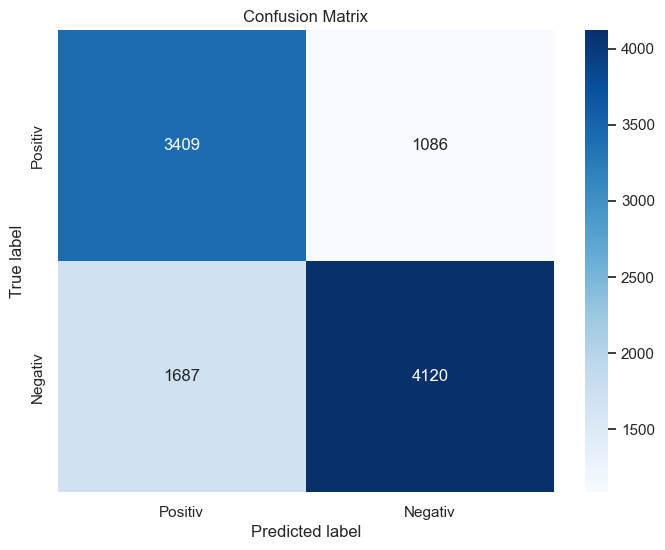

Classification Report:
               precision    recall  f1-score   support

     Negativ       0.71      0.79      0.75      5206
     Positiv       0.76      0.67      0.71      5096

    accuracy                           0.73     10302
   macro avg       0.73      0.73      0.73     10302
weighted avg       0.73      0.73      0.73     10302



In [ ]:
# Importering av VotingClassifier så att man kan kombindera de tre modeller med bästa parametrar samt importering av confusion_matrix, ConfusionMatrixDisplay samt classifcation report för att kunna utvärdera
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Skapar random state
np.random.seed(42)

# Kombinerar tränings- och valideringsdata från df_model2 scaled standard
X_train_full = np.concatenate((X_train_scaled2, X_val_scaled2), axis=0)
y_train_full = np.concatenate((y_train2, y_val2), axis=0)

# Återskapar modellerna med de bästa parametrarna från grid searchen
linear_svc_best = LinearSVC(max_iter=10000, C=100)
knn_best = KNeighborsClassifier(n_neighbors=9, p=1)
rf_best = RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200)

# Skapa ensemble-modellen med VotingClassifier
ensemble_model = VotingClassifier(
    estimators=[
        ("LinearSVC", linear_svc_best),
        ("KNN", knn_best),
        ("RandomForest", rf_best)],
    voting="hard") # hard innebär voting för majoritetsbeslut

# Tränar ensemble-modellen på hela tränings tillsammans valideringsdatan
ensemble_model.fit(X_train_full, y_train_full)

# Prediktion och utvärdering på testdatan
y_test_pred = ensemble_model.predict(X_test_scaled2)

# Räknar ut den standardmässiga confusion matrix. Det returnerar [ [TN, FP], [FN, TP] ]
cm = confusion_matrix(y_test2, y_test_pred)

# Omarrangera confusion matrix så att den visas som [TP, FP]
                                                  # [FN, TN]
tn, fp, fn, tp = cm.ravel()
new_cm = np.array([[tp, fp],
                   [fn, tn]])

# Visar den anpassade confusion matrixen med ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    new_cm,
    annot=True,          # Visa siffrorna
    fmt='d',             # Heltalsformat
    cmap='Blues',        # Färgskala
    xticklabels=["Positiv", "Negativ"], # Namnger x-axel värderna
    yticklabels=["Positiv", "Negativ"]) # Namnger y-axel värderna

# Ändrar plotens utseende
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Skriver ut classification report
report = classification_report(y_test2, y_test_pred, target_names=["Negativ", "Positiv"])
print("Classification Report:\n", report)

In [27]:
"""
References
1. python-programming-APTI-DZHAMURZAEV (2025, mars 25). Github. Retrieved from: https://github.com/AptiDz/python-programming-APTI-DZHAMURZAEV
2. Linjär algebra AI24 GBG (2025, mars 26). ITHS distans. Retrieve from: https://www.ithsdistans.se/course/view.php?id=1585
3. data-behandling-APTI-DZHAMURZAEV (2025, mars 28). Github. Retrieved from: https://github.com/AptiDz/data-behandling-APTI-DZHAMURZAEV
4. statistiska_metoder (2025, mars 28). Github. Retrieved from: https://github.com/AptiDz/statistiska_metoder
5. Machine-learning-AI24 (2025, mars 29). Github. Retrieved from: https://github.com/AptiDz/Machine-learning-AI24
6. Complete A.I. & Machine Learning, Data Science Bootcamp (2025, mars 29). (Andrei Neagoie, Daniel Bourke). Udemy. Retrieved from: https://www.udemy.com/course/complete-machine-learning-and-data-science-zero-to-mastery/
"""

'\nReferences\n1. python-programming-APTI-DZHAMURZAEV (2025, mars 25). Github. Retrieved from: https://github.com/AptiDz/python-programming-APTI-DZHAMURZAEV\n2. Linjär algebra AI24 GBG (2025, mars 26). ITHS distans. Retrieve from: https://www.ithsdistans.se/course/view.php?id=1585\n3. data-behandling-APTI-DZHAMURZAEV (2025, mars 28). Github. Retrieved from: https://github.com/AptiDz/data-behandling-APTI-DZHAMURZAEV\n4. statistiska_metoder (2025, mars 28). Github. Retrieved from: https://github.com/AptiDz/statistiska_metoder\n5. Machine-learning-AI24 (2025, mars 29). Github. Retrieved from: https://github.com/AptiDz/Machine-learning-AI24\n6. Complete A.I. & Machine Learning, Data Science Bootcamp (2025, mars 29). (Andrei Neagoie, Daniel Bourke). Udemy. Retrieved from: https://www.udemy.com/course/complete-machine-learning-and-data-science-zero-to-mastery/\n'